<a href="https://colab.research.google.com/github/rsouza-ufrpe/metodos-numericos/blob/main/ED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def direction_field(f, t_range, y_range, density=20, ax=None,
                    normalize=True, seg_len=0.9, pivot="mid",
                    color=None, linewidth=0.8):
    """
    Plota o campo de direção para a EDO y' = f(t, y).

    Params
    ------
    f : callable
        Função f(t, y).
    t_range : tuple (tmin, tmax)
    y_range : tuple (ymin, ymax)
    density : int
        Número de pontos em cada eixo (malha density x density).
    normalize : bool
        Se True, normaliza os vetores para terem mesmo comprimento.
    seg_len : float
        Comprimento visual dos segmentos (escala para quiver).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    tmin, tmax = t_range
    ymin, ymax = y_range

    T = np.linspace(tmin, tmax, density)
    Y = np.linspace(ymin, ymax, density)
    TT, YY = np.meshgrid(T, Y)

    # Inclinações m = f(t,y)
    M = f(TT, YY)

    # Vetor tangente (dt, dy) = (1, m)
    U = np.ones_like(M)   # componente em t
    V = M                 # componente em y

    if normalize:
        N = np.sqrt(U**2 + V**2)
        # evita divisão por zero (casos muito raros)
        N = np.where(N == 0, 1.0, N)
        U = U / N
        V = V / N

    # quiver desenha setas; com headlength=0 etc fica como "segmentos"
    ax.quiver(
        TT, YY, U, V,
        angles="xy", pivot=pivot, color=color,
        headlength=0, headwidth=0, headaxislength=0,
        linewidth=linewidth, scale_units="xy", scale=1/seg_len
    )

    ax.set_xlim(tmin, tmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("t")
    ax.set_ylabel("y")
    ax.set_title(r"Campo de direção para $y' = f(t,y)$")
    ax.grid(True, alpha=0.25)

    return ax


def euler_solve(f, t0, y0, t1, n=200):
    """Solução numérica simples por Euler explícito (pra sobrepor trajetórias)."""
    t = np.linspace(t0, t1, n+1)
    y = np.empty_like(t)
    y[0] = y0
    h = (t1 - t0) / n
    for k in range(n):
        y[k+1] = y[k] + h * f(t[k], y[k])
    return t, y


def plot_with_solutions(f, t_range, y_range, y0_list,
                        density=20, euler_steps=600):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    direction_field(f, t_range, y_range, density=density, ax=ax, seg_len=0.8)

    tmin, tmax = t_range
    # plota algumas soluções (Euler) a partir de condições iniciais em t=tmin
    for y0 in y0_list:
        t, y = euler_solve(f, tmin, y0, tmax, n=euler_steps)
        ax.plot(t, y, lw=2)

    ax.set_title(r"Campo de direção + algumas soluções numéricas (Euler)")
    plt.show()


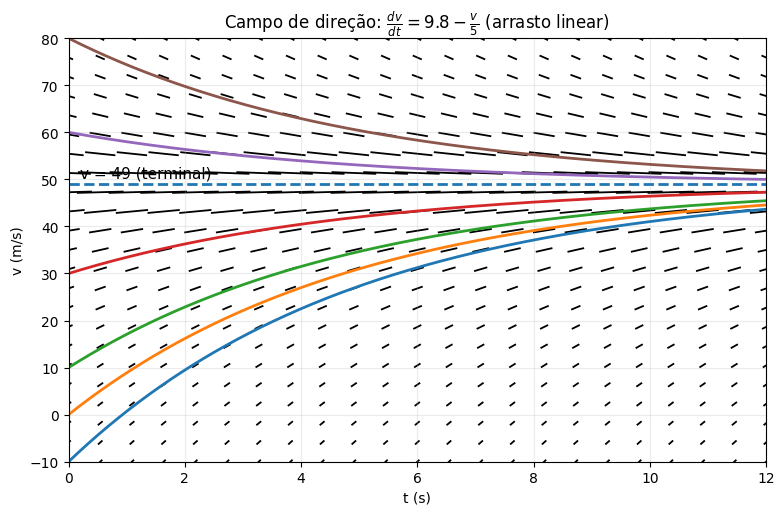

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def direction_field(f, t_range, y_range, density=22, ax=None,
                    normalize=True, seg_len=0.9, pivot="mid",
                    linewidth=0.8):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5.5))

    tmin, tmax = t_range
    ymin, ymax = y_range

    T = np.linspace(tmin, tmax, density)
    Y = np.linspace(ymin, ymax, density)
    TT, YY = np.meshgrid(T, Y)

    M = f(TT, YY)          # inclinações
    U = np.ones_like(M)    # dt
    V = M                  # dv

    if normalize:
        N = np.sqrt(U**2 + V**2)
        N = np.where(N == 0, 1.0, N)
        U, V = U/N, V/N

    ax.quiver(
        TT, YY, U, V,
        angles="xy", pivot=pivot,
        headlength=0, headwidth=0, headaxislength=0,
        linewidth=linewidth,
        scale_units="xy", scale=1/seg_len
    )

    ax.set_xlim(tmin, tmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("t (s)")
    ax.set_ylabel("v (m/s)")
    ax.grid(True, alpha=0.25)
    return ax

def euler_solve(f, t0, y0, t1, n=800):
    t = np.linspace(t0, t1, n+1)
    y = np.empty_like(t)
    y[0] = y0
    h = (t1 - t0) / n
    for k in range(n):
        y[k+1] = y[k] + h * f(t[k], y[k])
    return t, y

# --- Exemplo: queda com arrasto linear ---
g = 9.8
f = lambda t, v: g - v/5  # dv/dt = 9.8 - v/5
v_terminal = 5*g          # 49 m/s

t_range = (0, 12)
v_range = (-10, 80)

fig, ax = plt.subplots(figsize=(9, 5.5))

direction_field(f, t_range, v_range, density=23, ax=ax, seg_len=0.85)

# linha de equilíbrio (dv/dt=0)
ax.axhline(v_terminal, linestyle="--", linewidth=2)
ax.text(t_range[0] + 0.2, v_terminal + 1.5, "v = 49 (terminal)", fontsize=11)

# algumas soluções numéricas (condições iniciais)
for v0 in [-10, 0, 10, 30, 60, 80]:
    t, v = euler_solve(f, t_range[0], v0, t_range[1], n=1200)
    ax.plot(t, v, linewidth=2)

ax.set_title(r"Campo de direção: $\frac{dv}{dt}=9.8-\frac{v}{5}$ (arrasto linear)")
plt.show()
